# Interval edge colouring with z3 -- fastest encoding only

Five independent z3 optimizations (on top of `faster_version_reencoded.ipynb`'s
incremental push/pop + window-encoding baseline) were benchmarked head-to-head on a
genuinely hard instance: `K(2,2,3)`, which has **no** interval colouring up to 10
colours at all, so every technique has to fully prove `unsat` for k = 5..10.

Total wall-clock to prove that:

| variant | total time (s) |
|---|---|
| baseline (push/pop, Int) | 22.73 |
| symmetry breaking only | 15.66 |
| assumptions only | 11.34 |
| BitVec only | 4.80 |
| **BitVec + assumptions + symmetry (combined)** | **1.21** |

The combined technique won outright (~19x faster than baseline), so this notebook
keeps only that encoding -- no more re-running the same search 5 times just to
compare variants.

## 0. Graph + edge helpers (unchanged from the base notebook)

In [2]:
import time
import pygraphviz as pgv
from z3 import *


def create_graph(l, m, n):
    """Edges of the complete tripartite graph K(l, m, n)."""
    edges = []
    for i in range(0, l):
        for j in range(l, l + m):
            edges.append((i, j))
    for i in range(0, l):
        for k in range(l + m, l + m + n):
            edges.append((i, k))
    for j in range(l, l + m):
        for k in range(l + m, l + m + n):
            edges.append((j, k))
    return edges


def build_graph(l, m, n):
    """Build the AGraph for K(l, m, n). Returns (graph, name, layout)."""
    G = pgv.AGraph()
    G.node_attr['style'] = 'filled'
    G.edge_attr['dir'] = 'none'

    edges = create_graph(l, m, n)
    for i in range(l + m + n):
        G.add_node(i)
    for src, dst in edges:
        G.add_edge(src, dst)

    return (G, 'k_%d_%d_%d' % (l, m, n), 'circo')


def all_edges(graph):
    """All edges of `graph` as 'a b' strings."""
    return [u + ' ' + v for u, v in graph.edges()]


def incidence(edges):
    """vertex -> list of indices of edges touching it."""
    inc = {}
    for i, e in enumerate(edges):
        u, v = e.split(' ')
        inc.setdefault(u, []).append(i)
        inc.setdefault(v, []).append(i)
    return inc


## 1. The solver -- BitVec + assumptions + symmetry breaking

Three independent techniques stacked into one solver:

- **BitVec colours** instead of Int -- the colour domain is small and bounded, so
  Z3 bit-blasts straight to SAT instead of doing Simplex case-splits for every
  `Distinct` pair.
- **`check()` assumptions** instead of `push()`/`pop()` for the per-k upper bound --
  avoids solver-trail/scope bookkeeping on every k tried.
- **Symmetry breaking**: colours are only meaningful up to a constant shift, so
  `Or([x == 0 for x in xs])` pins the minimum colour to 0, collapsing every
  solution's whole shift-equivalent family into a single representative.

**Correctness note (BitVec wraparound):** `width` is sized with headroom
(`2 * max_colors`), and both `x` and `lo` (the per-vertex window start) are
explicitly fenced to `[0, max_colors - 1]`, so no arithmetic here can reach the
wraparound boundary.

In [3]:
def interval_coloring(graph, max_colors=None):
    """Interval edge colouring with z3 -- BitVec colours, assumption-based k
    search, and the minimum-colour-is-0 symmetry break. The fastest of five
    encodings benchmarked; see the notebook intro for numbers.

    Returns a result dict:
      {'solution': {edge:colour} or None, 'colorable': bool,
       'colours': k or None, 'colours_tested': int,
       'delta': int, 'max_colors': int}
    """
    edges = all_edges(graph)
    idx = {e: i for i, e in enumerate(edges)}
    inc = incidence(edges)

    delta = max(len(es) for es in inc.values())
    if max_colors is None:
        max_colors = 2 * delta

    width = max(4, (2 * max_colors).bit_length() + 2)
    xs = [BitVec('e%d' % i, width) for i in range(len(edges))]

    s = Solver()
    for x in xs:
        s.add(x >= 0, x <= max_colors - 1)
    s.add(Or([x == 0 for x in xs]))
    for v, es in inc.items():
        vs = [xs[i] for i in es]
        s.add(Distinct(vs))
        if len(vs) > 1:
            lo = BitVec('lo_%s' % v, width)
            s.add(lo >= 0, lo <= max_colors - 1)
            for x in vs:
                s.add(x >= lo, x <= lo + (len(vs) - 1))

    tested = 0
    for k in range(delta, max_colors + 1):
        tested += 1
        if s.check([x <= k - 1 for x in xs]) == sat:
            m = s.model()
            sol = {e: m[xs[idx[e]]].as_long() for e in edges}
            return {'solution': sol, 'colorable': True, 'colours': k,
                    'colours_tested': tested, 'delta': delta, 'max_colors': max_colors}

    return {'solution': None, 'colorable': False, 'colours': None,
            'colours_tested': tested, 'delta': delta, 'max_colors': max_colors}

## 2. Profiled version -- same stats table as `faster_version_reencoded.ipynb`

`interval_coloring_profiled` is `interval_coloring` with `Solver.statistics()`
captured (and printed) after every `check()` call: the same `k / sat / time(s) /
decisions / conflicts / propagations / restarts` table that section 4b of
`faster_version_reencoded.ipynb` prints for its baseline, so a row here and the
matching row there are directly comparable.

In [4]:
def _profile_search(s, xs, idx, edges, delta, max_colors, verbose=True, k_values=None):
    """Assumption-based k-loop + Solver.statistics() capture.

    `k_values` overrides the default delta..max_colors sweep -- pass a
    single-element list (e.g. [7]) to check just one k, such as a colour
    count already proven by a theorem, instead of searching.
    """
    if k_values is None:
        k_values = range(delta, max_colors + 1)
    if verbose:
        print('%-4s %-6s %-8s %-10s %-10s %-13s %-9s' %
              ('k', 'sat', 'time(s)', 'decisions', 'conflicts', 'propagations', 'restarts'))
    stats = []
    for k in k_values:
        t0 = time.time()
        outcome = s.check([x <= k - 1 for x in xs])
        elapsed = time.time() - t0

        st = s.statistics()
        d = {key: st.get_key_value(key) for key in st.keys()}
        row = {'k': k, 'sat': outcome == sat, 'time': elapsed,
               'decisions': d.get('decisions', 0), 'conflicts': d.get('conflicts', 0),
               'propagations': d.get('propagations', 0), 'restarts': d.get('restarts', 0)}
        stats.append(row)
        if verbose:
            print('%-4d %-6s %-8.4f %-10d %-10d %-13d %-9d' %
                  (row['k'], row['sat'], row['time'], row['decisions'],
                   row['conflicts'], row['propagations'], row['restarts']))

        if outcome == sat:
            m = s.model()
            sol = {e: m[xs[idx[e]]].as_long() for e in edges}
            return {'solution': sol, 'colorable': True, 'colours': k,
                    'colours_tested': len(stats), 'delta': delta, 'max_colors': max_colors,
                    'k_tested_range': (stats[0]['k'], stats[-1]['k'])}, stats

    return {'solution': None, 'colorable': False, 'colours': None,
            'colours_tested': len(stats), 'delta': delta, 'max_colors': max_colors,
            'k_tested_range': (stats[0]['k'], stats[-1]['k']) if stats else None}, stats


def interval_coloring_profiled(graph, max_colors=None, fixed_k=None, verbose=True):
    """Same encoding as interval_coloring (BitVec + assumptions + symmetry
    breaking), but records/prints Solver.statistics() for every k.

    `fixed_k`: if given, skip the upward search entirely and check only this
    one k (used when a theorem has already proven the graph is colourable
    with exactly `fixed_k` colours -- this just builds the concrete edge
    assignment at that k instead of re-discovering it by search).

    Returns (res, stats) -- res matches interval_coloring's return value
    (plus 'k_tested_range': (first_k, last_k) actually checked); stats is a
    list of one dict per k tried: {'k', 'sat', 'time', 'decisions',
    'conflicts', 'propagations', 'restarts'}.
    """
    edges = all_edges(graph)
    idx = {e: i for i, e in enumerate(edges)}
    inc = incidence(edges)
    delta = max(len(es) for es in inc.values())

    if fixed_k is not None:
        max_colors = max(max_colors or 2 * delta, fixed_k)
        k_values = [fixed_k]
    else:
        if max_colors is None:
            max_colors = 2 * delta
        k_values = None

    width = max(4, (2 * max_colors).bit_length() + 2)
    xs = [BitVec('e%d' % i, width) for i in range(len(edges))]

    s = Solver()
    for x in xs:
        s.add(x >= 0, x <= max_colors - 1)
    s.add(Or([x == 0 for x in xs]))
    for v, es in inc.items():
        vs = [xs[i] for i in es]
        s.add(Distinct(vs))
        if len(vs) > 1:
            lo = BitVec('lo_%s' % v, width)
            s.add(lo >= 0, lo <= max_colors - 1)
            for x in vs:
                s.add(x >= lo, x <= lo + (len(vs) - 1))

    return _profile_search(s, xs, idx, edges, delta, max_colors, verbose, k_values=k_values)

## 3. Solution → matrix

`color_matrix` turns an edge-colour solution into a matrix, `*` marks cells with no edge, including the diagonal. `format_matrix` renders it as aligned text for saving/printing. `log_solution` appends a run's summary + matrix to `solutions.txt`, the same way `faster_version_reencoded.ipynb` does.

In [5]:
def color_matrix(graph, solution, node_names=None):
    """edge-colour matrix; '*' where there is no edge. Row/col headers use
    node_names[index] when given, else the raw node id."""
    nodes = sorted(graph.nodes(), key=int)
    idx = {node: i for i, node in enumerate(nodes)}
    M = [['*'] * len(nodes) for _ in nodes]
    for e_str, color in solution.items():
        u, v = e_str.split(' ')
        M[idx[u]][idx[v]] = str(color)
        M[idx[v]][idx[u]] = str(color)
    labels = [str(node_names[int(nd)]) if node_names and int(nd) in node_names else nd
              for nd in nodes]
    return labels, M


def format_matrix(nodes, M):
    """Render the matrix as aligned text with node labels on row/col."""
    w = max([len(x) for row in M for x in row] + [len(x) for x in nodes]) + 1
    lines = [' ' * w + ''.join(x.rjust(w) for x in nodes)]
    for label, row in zip(nodes, M):
        lines.append(label.rjust(w) + ''.join(x.rjust(w) for x in row))
    return '\n'.join(lines)


def format_kmn(name, solution, node_names=None):
    """
    Rows = part A (size l) then part B (size m); columns = part A (size l)
    then part C (size n). '*' marks no-edge cells (the A x A block).
    Row/column headers show node_names[index] when given, else the plain
    node index.
    """
    l, m, n = (int(t) for t in name.split('_')[1:])
    row_nodes = [str(v) for v in range(l + m)]                              # A, then B
    col_nodes = [str(v) for v in list(range(l)) + list(range(l + m, l + m + n))]  # A, then C

    def label(nd):
        i = int(nd)
        return str(node_names[i]) if node_names and i in node_names else nd

    def cell(u, v):
        c = solution.get(u + ' ' + v)
        if c is None:
            c = solution.get(v + ' ' + u)
        return '*' if c is None else str(c)

    grid = [[cell(r, c) for c in col_nodes] for r in row_nodes]
    row_labels = [label(r) for r in row_nodes]
    col_labels = [label(c) for c in col_nodes]

    w = max([len(x) for row in grid for x in row] +
            [len(x) for x in row_labels] + [len(x) for x in col_labels])
    header = ' ' * w + ' | ' + ' | '.join(x.rjust(w) for x in col_labels) + ' |'
    rows_txt = [row_labels[i].rjust(w) + ' | ' + ' | '.join(x.rjust(w) for x in grid[i]) + ' |'
                for i in range(len(row_nodes))]
    width = max([len(header)] + [len(r) for r in rows_txt])
    rule = '-' * width

    lines = [('K ' + ' '.join(str(s) for s in (l, m, n))).center(width), '',
             header, rule]
    for r in rows_txt:
        lines.append(r)
        lines.append(rule)
    return '\n'.join(lines)


def render_matrix(name, graph, solution, node_names=None):
    parts = name.split('_')
    if parts[0] == 'k' and len(parts) == 4 and all(p.isdigit() for p in parts[1:]):
        return format_kmn(name, solution, node_names)
    nodes, M = color_matrix(graph, solution, node_names)
    return format_matrix(nodes, M)


def log_solution(name, graph, res, runtime, path='solutions.txt', node_names=None):
    """Append a summary of one run to the combined solutions file: runtime,
    how many colour-counts were tested, whether the graph was colourable,
    which theorem decided it (if any), and (if colourable) the solution
    matrix.
    Entries accumulate across runs."""

    if res['colours_tested'] == 0:
        tested_str = '0 (skipped -- decided by proven theorem)'
    elif res.get('k_tested_range'):
        lo, hi = res['k_tested_range']
        tested_str = '%d  (k = %d .. %d)' % (res['colours_tested'], lo, hi)
    else:
        lo = res['delta']
        hi = lo + res['colours_tested'] - 1
        tested_str = '%d  (k = %d .. %d)' % (res['colours_tested'], lo, hi)
    lines = ['=== %s ===' % name,
             'colourable     : %s' % ('yes' if res['colorable'] else 'no'),
             'colours tested : %s' % tested_str,
             'runtime        : %.3f s' % runtime]
    if res.get('theorem'):
        lines.append('decided by     : %s' % res['theorem'])
    if res['colorable']:
        lines.append('colours used   : %d' % res['colours'])
        lines.append('solution matrix:')
        lines.append(render_matrix(name, graph, res['solution'], node_names))
    lines.append('')
    with open(path, 'a') as f:
        f.write('\n'.join(lines) + '\n')
    print('Appended result for %s to %s' % (name, path))

## 3b. Proven theorems

Structural results proven for specific `(l, m, n)` shapes of `K(l, m, n)`,
checked *before* the solver runs, in citation order, first match wins (no
"Theorem 8" -- intentionally skipped). The graph is symmetric under
permuting its three parts, so every check tries all orderings of
`(l, m, n)`, not just the one given.

Every theorem here states an exact colour count, so a match is always
decisive: `check_theorems` returns either `colorable: False` (solver
skipped entirely) or `colorable: True, colours: w` (the solver is then
called *once*, fixed at `k = w`, only to construct the concrete edge
assignment -- never to search for or re-verify `w`). Each result also
carries the literal `theorem` statement, so it can be cited in the printed
output and in `solutions.txt`.
https://api.nla.am/server/api/core/bitstreams/2f194968-cb92-4e1a-9782-ed223528788f/content

In [6]:
import itertools
import math

THEOREM_1 = 'Theorem 1: gcd(m+1, n+1) = 1 => K(1,m,n) is colorable, w = m+n'
THEOREM_2 = 'Theorem 2: gcd(m+1, n+1) > 1 => K(1,m,n) is NOT colorable'
THEOREM_3 = 'Theorem 3: K(l,m,l+m) is colorable, w = 2l + 2m - 1'
THEOREM_4 = 'Theorem 4: K(2n,2n+1,2n+2) is colorable, w = 8n + 2'
THEOREM_5 = 'Theorem 5: l≥2, m≥2, k≥1 => K(l,m,k(l+m)) is colorable, w = (k+1)(l+m) - 1'
THEOREM_6 = 'Theorem 6: for all k>=1: K(2,3k+1,3k+4) is colorable, w = 6k + 6'
# Theorem 7 (7a/7b/7c) -- NEEDS TO BE CHECKED. Found to overshoot the true minimum
# by exactly 1 on several K(2,2,n) graphs (e.g. K(2,2,6): 7b claims w=9, the real
# solved minimum is 8). Not only a boundary/m=2 issue -- Theorems 3 and 5 show the
# same +1 overshoot on other n in that family, so this needs re-verification against
# the source paper before any of 7a/7b/7c are trusted again. Disabled below in the
# meantime (commented out of both the function definitions and THEOREM_CHECKS).
THEOREM_7A = 'Theorem 7a: for all k≥1, m>2: K(2,m,m) is colorable, w = 2m + 1'
THEOREM_7B = 'Theorem 7b: for all k≥1, m≥2: K(2,m,m+k(m+2)) is colorable, w = (k+1)(m+2) + m - 1'
THEOREM_7C = 'Theorem 7c: for all m>2: K(2,2,2(m-1)) is colorable, w = 2m + 1'
THEOREM_9 = 'Theorem 9: for all k=2m, m>0: K(2,2,2k+1) is NOT colorable'
THEOREM_10 = 'Theorem 10: for all k=2m+1, m>0: K(2,2,2k+1) is NOT colorable'


def theorem_k1mn(l, m, n):
    """Theorems 1 & 2: K(1, m, n) -- decided by gcd(m+1, n+1)."""
    for a, b, c in itertools.permutations((l, m, n)):
        if a == 1:
            if math.gcd(b + 1, c + 1) == 1:
                return {'colorable': True, 'colours': b + c, 'theorem': THEOREM_1}
            return {'solution': None, 'colorable': False, 'colours': None,
                    'colours_tested': 0, 'theorem': THEOREM_2}
    return None


def theorem_3(l, m, n):
    """K(l, m, l+m) -- one part is the sum of the other two."""
    for a, b, c in itertools.permutations((l, m, n)):
        if c == a + b:
            return {'colorable': True, 'colours': 2 * a + 2 * b - 1, 'theorem': THEOREM_3}
    return None


def theorem_4(l, m, n):
    """K(2t, 2t+1, 2t+2) -- three consecutive parts, smallest even."""
    a, b, c = sorted((l, m, n))
    if b == a + 1 and c == a + 2 and a % 2 == 0 and a >= 2:
        t = a // 2
        return {'colorable': True, 'colours': 8 * t + 2, 'theorem': THEOREM_4}
    return None


def theorem_5(l, m, n):
    """K(l, m, k(l+m)), l>=2, m>=2, k>=1."""
    for a, b, c in itertools.permutations((l, m, n)):
        if a >= 2 and b >= 2 and c % (a + b) == 0:
            k = c // (a + b)
            if k >= 1:
                return {'colorable': True, 'colours': (k + 1) * (a + b) - 1, 'theorem': THEOREM_5}
    return None


def theorem_6(l, m, n):
    """K(2, 3k+1, 3k+4), k>=1."""
    for a, b, c in itertools.permutations((l, m, n)):
        if a == 2 and c == b + 3 and (b - 1) % 3 == 0:
            k = (b - 1) // 3
            if k >= 1:
                return {'colorable': True, 'colours': 6 * k + 6, 'theorem': THEOREM_6}
    return None


# def theorem_7a(l, m, n):
#     """K(2, m, m), m>2 -- m=2 (K(2,2,2)) is excluded: it's fully symmetric and
#     actually colourable with delta=4 colours, one better than this formula's 2m+1=5,
#     so it must fall through to a real solve instead of being claimed by this theorem."""
#     for a, b, c in itertools.permutations((l, m, n)):
#         if a == 2 and b == c and b > 2:
#             return {'colorable': True, 'colours': 2 * b + 1, 'theorem': THEOREM_7A}
#     return None


# def theorem_7b(l, m, n):
#     """K(2, m, m+k(m+2)), m>=2, k>=1."""
#     for a, b, c in itertools.permutations((l, m, n)):
#         if a == 2 and b >= 2 and c > b and (c - b) % (b + 2) == 0:
#             k = (c - b) // (b + 2)
#             if k >= 1:
#                 return {'colorable': True, 'colours': (k + 1) * (b + 2) + b - 1, 'theorem': THEOREM_7B}
#     return None


# def theorem_7c(l, m, n):
#     """K(2, 2, 2(t-1)) -- two parts are 2, the third is even, t>2 (third>2).
#     w = 2t+1 with t = third/2 + 1, i.e. w = third + 3. third=2 (t=2, i.e. K(2,2,2))
#     is excluded: that's the fully symmetric case, actually colourable with delta=4
#     colours, one better than this formula's third+3=5, so it must fall through to a
#     real solve instead of being claimed by this theorem."""
#     vals = [l, m, n]
#     if vals.count(2) >= 2:
#         rest = vals[:]
#         rest.remove(2)
#         rest.remove(2)
#         third = rest[0] if rest else 2
#         if third % 2 == 0 and third > 2:
#             return {'colorable': True, 'colours': third + 3, 'theorem': THEOREM_7C}
#     return None


def theorem_9_10(l, m, n):
    """Theorems 9 & 10 combined: K(2, 2, n), n odd and n>=5 -- NOT
    colorable (n=1 mod 4 -> Theorem 9, n=3 mod 4 -> Theorem 10; together
    these cover every odd n>=5)."""
    vals = [l, m, n]
    if vals.count(2) >= 2:
        rest = vals[:]
        rest.remove(2)
        rest.remove(2)
        third = rest[0] if rest else 2
        if third % 2 == 1 and third >= 5:
            stmt = THEOREM_9 if third % 4 == 1 else THEOREM_10
            return {'solution': None, 'colorable': False, 'colours': None,
                    'colours_tested': 0, 'theorem': stmt}
    return None


THEOREM_CHECKS = [theorem_3, theorem_4, theorem_5, theorem_6,
                   theorem_9_10]  # theorem_7a, theorem_7b, theorem_7c disabled -- see comment above


def check_theorems(l, m, n):
    """Try every proven theorem, in citation order; return the first result
    that applies (None if none do). Trusted as proven -- not re-verified by
    the solver.

    theorem_k1mn runs first and unconditionally, since it is unaffected by
    the issue below. After that, K(2,2,n)-shaped graphs (two of the three
    parts both exactly 2) skip every remaining theorem and fall through to
    a real solve: Theorems 3, 5, 7a, 7b, and 7c were all found to overshoot
    the true minimum by exactly 1 on this family (e.g. K(2,2,6): Theorem 7b
    claims w=9, the real solved minimum is 8) -- see the comment above
    Theorem 7's definitions. This is a targeted guard, not a blanket
    disable: Theorem 3 and Theorem 5 stay active for every other shape
    they match (e.g. K(3,4,7), K(3,5,16)), where they're unverified but
    unchallenged.
    """
    result = theorem_k1mn(l, m, n)
    if result is not None:
        return result
    if [l, m, n].count(2) >= 2:
        # Only theorem_9_10 (the not-colorable claims) has been verified
        # correct on this shape (checked K(2,2,5) against a real solve,
        # genuinely unsat up to the 2*delta cap). theorem_3 and theorem_5
        # overshoot here, so they're skipped -- everything else in
        # THEOREM_CHECKS never matches a double-2 graph anyway.
        return theorem_9_10(l, m, n)
    for fn in THEOREM_CHECKS:
        result = fn(l, m, n)
        if result is not None:
            return result
    return None

## 4. Run

Build K(l, m, n) and colour its edges with `interval_coloring_profiled`, printing
the per-k solver-effort table followed by a summary.

In [14]:
l,m,n = 2,2,2

In [15]:
G, gname, _ = build_graph(l, m, n)

In [18]:
# Optional: give nodes more readable names (letters, words, ...) instead of
# their plain index. Used when rendering the solution matrix (log_solution /
# render_matrix) -- any index left out of the dict just keeps its numeric
# label, so this is safe to leave as-is.
node_names = {i: str(i) for i in range(l + m + n)}

# >>> CUSTOMIZE HERE, e.g.: <<<
node_names[0] = 'Jade'
node_names[1] = 'Joy'

node_names[2] = 'Kate'
node_names[3] = 'Ani'

node_names[4] = 'Mia'
node_names[5] = 'Zoe'

# node_names[6] = 'G6'
# node_names[7] = 'G7'
# node_names[8] = 'G8'
# node_names[9] = 'G9'

print('Part A (size %d): indices %s' % (l, list(range(l))))
print('Part B (size %d): indices %s' % (m, list(range(l, l + m))))
print('Part C (size %d): indices %s' % (n, list(range(l + m, l + m + n))))

Part A (size 2): indices [0, 1]
Part B (size 2): indices [2, 3]
Part C (size 2): indices [4, 5]


In [19]:
thm = check_theorems(l, m, n)

if thm is not None:
    if thm['colorable']:
        print('Theorem check for %s: colorable with %d colours' % (gname, thm['colours']))
    else:
        print('Theorem check for %s: NOT colorable -- skipping solver' % gname)
    print(thm['theorem'])
    print()

t1 = time.time()
if thm is not None and not thm['colorable']:
    res, stats = thm, []
elif thm is not None and thm['colorable']:
    print('Building the solution directly at %d colours (no search).' % thm['colours'])
    print()
    res, stats = interval_coloring_profiled(G, fixed_k=thm['colours'])
    res['theorem'] = thm['theorem']
else:
    print('Solving %s with the combined encoding (BitVec + assumptions + symmetry-breaking)' % gname)
    print()
    res, stats = interval_coloring_profiled(G)
t2 = time.time()
runtime = t2 - t1

print()
if res['colorable']:
    print('Minimum colours for an interval colouring: %d' % res['colours'])
    print('  (max degree Delta = %d is a hard lower bound)' % res['delta'])
elif thm is not None:
    print('No interval colouring exists for %s (proven by theorem, any k)' % gname)
    print(thm['theorem'])
else:
    print('No interval colouring found with up to %d colours' % res['max_colors'])
if thm is not None and thm['colorable']:
    print('Colour counts tested: %d (built directly at the theorem-proven k, no search)' % res['colours_tested'])
elif thm is not None:
    print('Colour counts tested: %d (decided by theorem, no search)' % res['colours_tested'])
else:
    print('Colour counts tested: %d (searched upward from Delta)' % res['colours_tested'])
print('Total solve time: %.4fs' % sum(row['time'] for row in stats))

# save this run to the combined solutions file
log_solution(gname, G, res, runtime, node_names=node_names)

Solving k_2_2_2 with the combined encoding (BitVec + assumptions + symmetry-breaking)

k    sat    time(s)  decisions  conflicts  propagations  restarts 
4    True   0.0065   124        20         2392          0        

Minimum colours for an interval colouring: 4
  (max degree Delta = 4 is a hard lower bound)
Colour counts tested: 1 (searched upward from Delta)
Total solve time: 0.0065s
Appended result for k_2_2_2 to solutions.txt


## 4b. Per-k solver effort (visualizing the search)

`interval_coloring_profiled` already records `Solver.statistics()` for every
`k` it tries (section 2) -- this just charts the `stats` list instead of only
printing it. Green bars are `sat` calls, red bars are `unsat` calls; on a hard
instance like `K(2,2,7)` almost all the height should be red, since proving a
`k` too small is what actually costs time -- the eventual `sat` call that
finds the answer is comparatively cheap.

In [20]:
# import matplotlib.pyplot as plt

# ks = [d['k'] for d in stats]
# times = [d['time'] for d in stats]
# decisions = [d['decisions'] for d in stats]
# conflicts = [d['conflicts'] for d in stats]
# bar_colors = ['#2ca02c' if d['sat'] else '#d62728' for d in stats]   # green = sat, red = unsat

# fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# axes[0].bar(ks, times, color=bar_colors)
# axes[0].set_ylabel('time (s)')
# axes[0].set_title('Per-k solver effort for %s   (green = sat, red = unsat)' % gname)

# width = 0.4
# axes[1].bar([k - width / 2 for k in ks], decisions, width=width, color=bar_colors, alpha=0.9, label='decisions')
# axes[1].bar([k + width / 2 for k in ks], conflicts, width=width, color=bar_colors, alpha=0.4, label='conflicts')
# # spans several orders of magnitude on hard instances -> try axes[1].set_yscale('log') then
# axes[1].set_ylabel('count')
# axes[1].set_xlabel('k (number of colours tried)')
# axes[1].set_xticks(ks)
# axes[1].legend()

# plt.tight_layout()
# plt.show()

## 5. Draw the coloured graph

Draws the graph with each part on its own row (same colour per row) and edges coloured + labelled with their colour number. Change `part_fill` for the node/row colours and `edge_palette` for the edge colours.

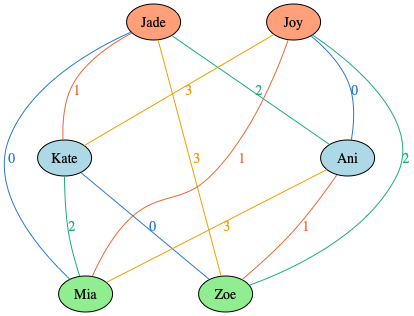

In [21]:
# Draw the coloured graph: nodes coloured by part (same row = same colour).
# Layout rules:
#   * every part sits on its own horizontal line,
#   * the part with the FEWEST nodes is pinned to the TOP (2 nodes on top),
#   * the part with the MOST nodes is pinned to the BOTTOM,
#   * generous spacing + spline routing so nodes never overlap and edges
#     curve AROUND nodes instead of crossing over them,
#   * edges coloured and labelled with their colour number.
if not res['colorable']:
    print('No colouring to draw for %s.' % gname)
else:
    sol = res['solution']
    sizes = [int(t) for t in gname.split('_')[1:]]      # 'k_2_3_4' -> [2, 3, 4]

    # >>> CHANGE NODE COLOURS HERE (one per row/part) <<<
    part_fill = ['lightsalmon','lightblue', 'lightgreen', 'khaki', 'plum']

    edge_palette = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
                    '#e87ba4', '#008300', '#4a3aa7', '#e34948']
    n_colours = res['colours']
    if n_colours > len(edge_palette):
        import colorsys
        extra = n_colours - len(edge_palette)
        for i in range(extra):
            r, g, b = colorsys.hsv_to_rgb(i / extra, 0.65, 0.85)
            edge_palette.append('#%02x%02x%02x' % (int(r * 255), int(g * 255), int(b * 255)))

    # node index range for each ORIGINAL part: part p owns nodes [start, start+size)
    starts, node = [], 0
    for size in sizes:
        starts.append(node)
        node += size
    part_nodes_by_part = [[str(starts[p] + i) for i in range(sizes[p])]
                          for p in range(len(sizes))]

    # vertical order of the rows: smallest part on TOP, largest part on BOTTOM
    row_order = sorted(range(len(sizes)), key=lambda p: sizes[p])
    n_rows = len(row_order)

    # spacing so nodes never overlap and edges have room to route AROUND nodes
    G.graph_attr['nodesep'] = '0.6'    # horizontal gap between nodes in a row
    G.graph_attr['ranksep'] = '1.2'    # vertical gap between rows (room for splines)
    G.graph_attr['splines'] = 'true'   # draw edges as curves that avoid nodes

    for row_pos, p in enumerate(row_order):
        part_nodes = part_nodes_by_part[p]
        for nd in part_nodes:
            gnode = G.get_node(nd)
            gnode.attr['style'] = 'filled'
            gnode.attr['fillcolor'] = part_fill[p % len(part_fill)]
            gnode.attr['label'] = str(node_names.get(int(nd), nd))  # custom name, if any
        # top row -> rank 'min', bottom row -> rank 'max', middle rows -> 'same'
        rank = 'min' if row_pos == 0 else ('max' if row_pos == n_rows - 1 else 'same')
        sub = G.add_subgraph(part_nodes, name='row_%d' % row_pos, rank=rank)
        # invisible chain keeps the row in increasing left-to-right order
        for a, b in zip(part_nodes, part_nodes[1:]):
            sub.add_edge(a, b, style='invis')

    # colour AND number each edge
    for e_str, color in sol.items():
        u, v = e_str.split(' ')
        e = G.get_edge(u, v)
        c = edge_palette[color]
        e.attr['color'] = c
        e.attr['fontcolor'] = c
        e.attr['label'] = str(color)

    from IPython.display import Image, display
    # prog='dot' forces the layered engine that stacks the rows.
    # (pygraphviz's draw() defaults to neato, which would scramble the rows.)
    display(Image(G.draw(prog='dot', format='png')))   # show inline (NOT saved to disk)

## 6. Save graph + matrix to HTML

Same as `faster_version_reencoded.ipynb`'s HTML export: appends a section to
`solutions.html` with the run's stats, the solution matrix, and the coloured
graph image (base64-embedded PNG, using the same row layout as section 5).

In [22]:
import base64

png_bytes = G.draw(prog='dot', format='png')
out_path  = 'solutions.html'

html = ['<section style="font-family:monospace;text-align:center;'
        'max-width:800px;margin:24px auto;'
        'border-bottom:1px solid #ccc;padding-bottom:16px">']
html.append('<h2>%s</h2>' % gname)

# each field on its own line
html.append('<div>colourable: <b>%s</b></div>' % ('yes' if res['colorable'] else 'no'))
if res['colorable']:
    html.append('<div>colours used: <b>%d</b></div>' % res['colours'])
    html.append('<div>runtime: %.3f s</div>' % runtime)
    # solution matrix
    html.append('<pre style="background:#f6f6f6;padding:8px;'
                'display:inline-block;text-align:left">%s</pre>'
                % render_matrix(gname, G, res['solution'], node_names))
    # image
    b64 = base64.b64encode(png_bytes).decode('ascii')
    html.append('<div><img src="data:image/png;base64,%s" '
                'style="max-width:640px;border:1px solid #ddd"></div>' % b64)
html.append('</section>')

with open(out_path, 'a') as f:
    f.write('\n'.join(html) + '\n')
print('saved image + matrix ->', out_path)

saved image + matrix -> solutions.html
